In [1]:
# 1. Import Libraries


import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [2]:
# 2. Load CIFAR-10 Dataset


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [3]:
# 3. Data Augmentation


datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

In [4]:
# 4. Build CNN Model


model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Conv Layer 3
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 5. Compile Model


model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)


In [6]:
# 6. Train Model (with Augmentation)


history = model.fit(
datagen.flow(x_train, y_train, batch_size=64),
epochs=10,
validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 73ms/step - accuracy: 0.3233 - loss: 1.8185 - val_accuracy: 0.4646 - val_loss: 1.5108
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.4398 - loss: 1.5361 - val_accuracy: 0.5425 - val_loss: 1.2753
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.4887 - loss: 1.4302 - val_accuracy: 0.5609 - val_loss: 1.2259
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5191 - loss: 1.3493 - val_accuracy: 0.6111 - val_loss: 1.0913
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5400 - loss: 1.3049 - val_accuracy: 0.6178 - val_loss: 1.0914
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5594 - loss: 1.2593 - val_accuracy: 0.6168 - val_loss: 1.0792
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5696 - loss: 1.2188 - val_accuracy: 0.6394 - val_loss: 1.0366
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5791 - loss: 1.2017 - 

In [7]:
# 7. Evaluate Model


test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6678 - loss: 0.9520
Test Accuracy: 0.6678000092506409


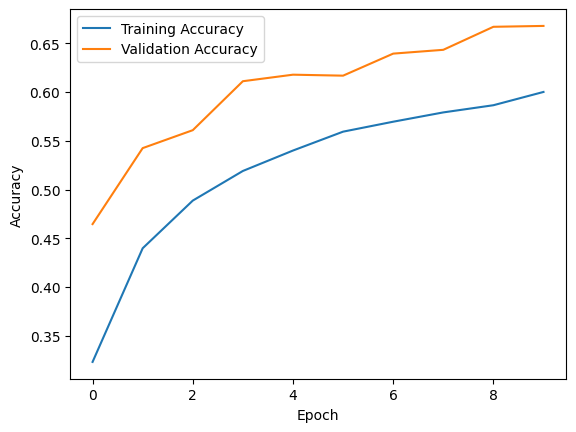

In [8]:
# 8. Plot Accuracy


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

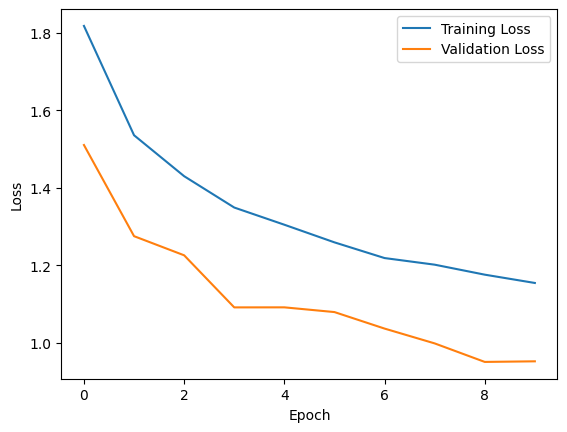

In [9]:
# 9. Plot Loss


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()